<a href="https://colab.research.google.com/github/raisharad/GenerativeAIandAgenticAI/blob/main/june6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np

First, let's create a DataFrame with 30 records. I'll use random values for 'age' and 'bmi', and randomly assign `True` or `False` for 'diabetes'.

In [15]:
# Generate 30 records for age, bmi, and diabetes
np.random.seed(42) # for reproducibility
ages = np.random.randint(18, 70, size=30)
bmis = np.random.uniform(18.0, 35.0, size=30).round(1)
diabetes = np.random.choice([True, False], size=30, p=[0.3, 0.7]) # 30% chance of diabetes

data = {
    'age': ages,
    'bmi': bmis,
    'diabetes': diabetes
}
df = pd.DataFrame(data)

# Display the first 5 rows of the created DataFrame
display(df.head())

,age,bmi,diabetes
0,56,23.0,True
1,69,28.4,False
2,46,20.4,False
3,32,23.0,False
4,60,24.2,False


Now, I'll save this DataFrame to a CSV file named `health_data.csv` in the current directory.

In [16]:
# Save the DataFrame to a CSV file
csv_filename = 'health_data.csv'
df.to_csv(csv_filename, index=False)

print(f"CSV file '{csv_filename}' created successfully with 30 records.")

CSV file 'health_data.csv' created successfully with 30 records.


In [17]:
import pandas as pd
from sklearn.tree  import DecisionTreeClassifier
# from sklearn.tree  import plot_tree # Removed as it's not needed for fitting and caused import error
# from matplotlib.pyplot import plt # Removed as it's not needed for fitting and caused import error

model=DecisionTreeClassifier(
    criterion='gini',
    splitter='best',
    max_depth=3,
    random_state=42
)

model.fit(df[['age','bmi']],df['diabetes'])

DecisionTreeClassifier(max_depth=3, random_state=42)

In [18]:
import pandas as pd
from sklearn.ensemble  import RandomForestClassifier # Corrected typo and imported from ensemble

model=RandomForestClassifier(
    n_estimators=10,
    max_depth=3,
    random_state=42
)

model.fit(df[['age','bmi']],df['diabetes'])

RandomForestClassifier(max_depth=3, n_estimators=10, random_state=42)

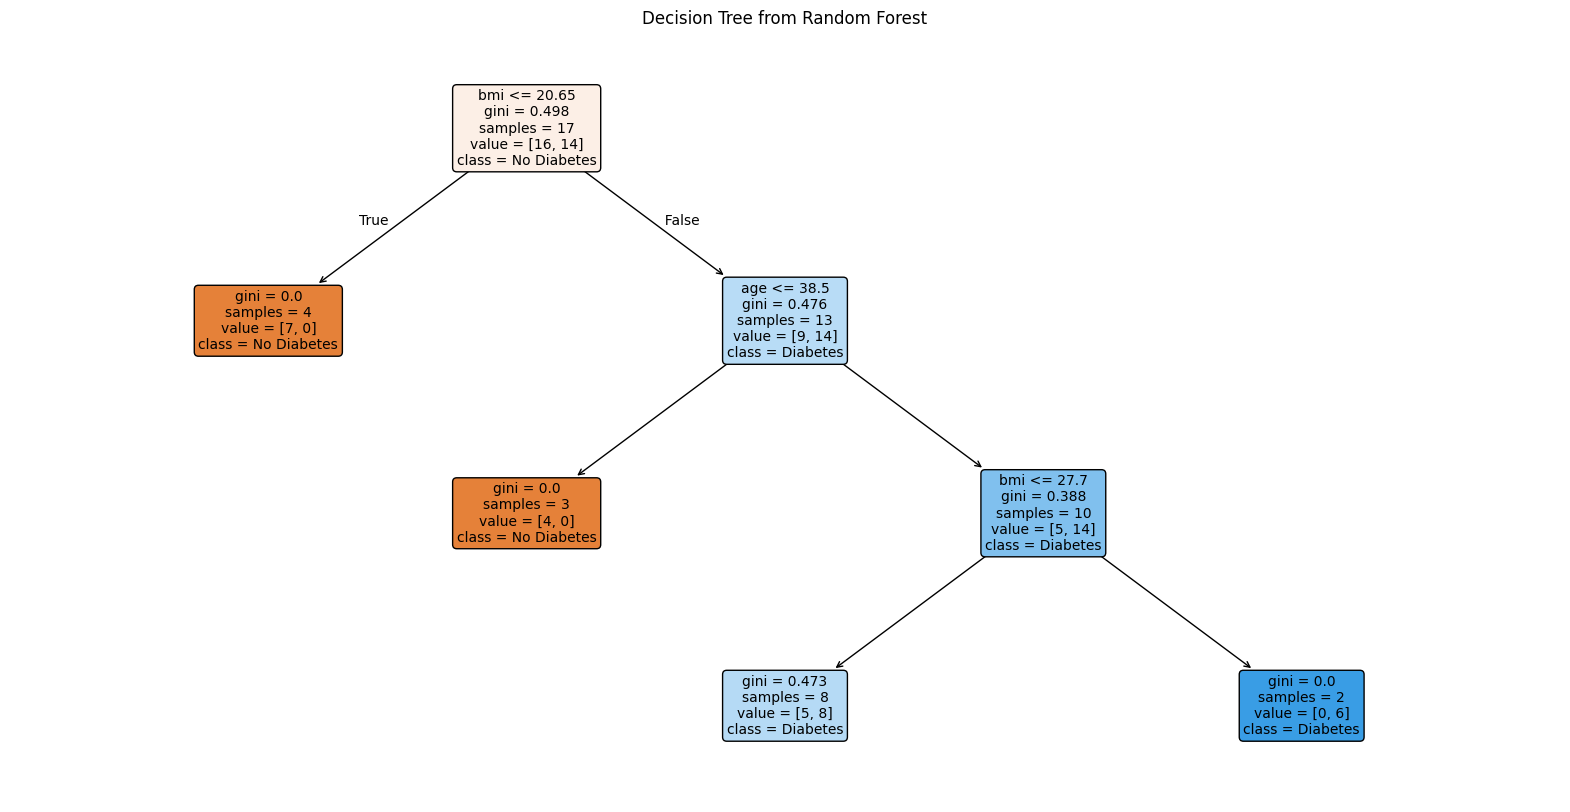

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(model.estimators_[0], # For RandomForest, we plot one of the individual trees
          feature_names=['age','bmi'],
          class_names=['No Diabetes', 'Diabetes'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree from Random Forest')
plt.show()

## K-Means Clustering

Now, let's perform K-Means clustering on the 'age' and 'bmi' features to identify potential groups within our dataset.

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data for clustering (features are 'age' and 'bmi')
X = df[['age', 'bmi']]

# Initialize and fit the KMeans model
# Let's start with 3 clusters, but this can be adjusted.
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is set to 'auto' by default from sklearn 1.4
kmeans.fit(X)

# Add the cluster labels to the original DataFrame
df['cluster'] = kmeans.labels_

# Display the first few rows with the new cluster column
display(df.head())

,age,bmi,diabetes,cluster
0,56,23.0,True,1
1,69,28.4,False,1
2,46,20.4,False,2
3,32,23.0,False,0
4,60,24.2,False,1


### Visualize the Clusters

Let's visualize the clusters to see how the data points are grouped based on 'age' and 'bmi'.

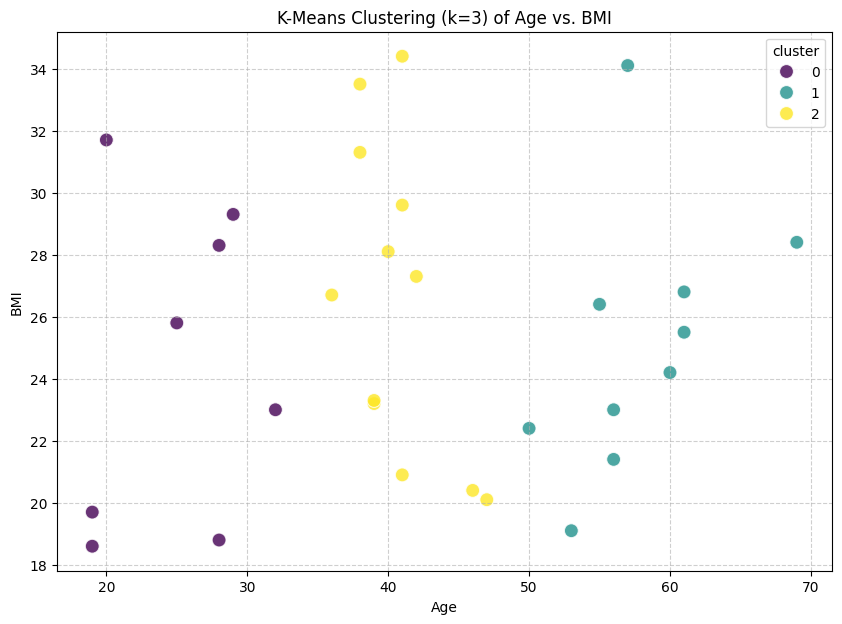

In [22]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='age', y='bmi', hue='cluster', markers=X , data=df, palette='viridis', s=100, alpha=0.8)
plt.title(f'K-Means Clustering (k={k}) of Age vs. BMI')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()